# Reading and mapping the GLEAM v4.3a zarr stores

This notebook opens the icechunk-backed zarr stores that `gleam_zarr.py` builds and
makes map plots from them with cartopy. It is a reader: every session here is
read-only and nothing writes back to a store.

**One store per variable.** The layout is the directory and the variable is the
filename, so the spatial layout is fourteen stores side by side:

```
<zarr>/spatial/gleam.v_4_3_a.day.native_0p1x0p1.<canonical_name>.zarr
```

A figure drawing on several variables opens several stores and merges them;
`open_family` below does that. The merge is sound because the siblings were
built from the same raw files onto the same grid and the same time axis, and
`verify_gleam_zarr.py` holds them to it.

**Canonical names.** The arrays carry the data engineering style guide's names
and units rather than GLEAM's: `evaporation` rather than `E`, `mm d-1` rather
than `mm.day-1`. The mapping is [nomenclature-key_gleam.md](nomenclature-key_gleam.md),
and `resolve_variable` reads either spelling — so the cells below go on naming
variables `E` and `SMrz`, the way the raw tree and the configs do, while the
stores answer to `evaporation` and `soil_moisture_root_zone`. What GLEAM
published is kept on each array as its `original_*` attributes.

The config supplies the download root and the store naming template, the same
ones the build and the verifier use, but *which* store to open is set in the
notebook: `VERSION`, `TEMPORAL_RESOLUTION`, `GRID_NAME` and `SUFFIX` pick a
layout out of that tree, and the variable picks one store within it.

Sections:

1. Open a store, and see what the layout holds
2. One day, one variable — a global map
3. The evaporation components on the same day
4. Monthly means, and a summer-minus-winter difference
5. A regional zoom on a projection that suits the region
6. The known data gap in `evaporation`, on a map
7. Time series: what this layout costs, and the sibling built for them

## 1. Open a store

`xr.open_zarr` reads the icechunk session's store rather than a directory path.
`consolidated=False` is required: icechunk keeps its own manifest and does not
write a consolidated zarr metadata document.

The store settings are substituted into the config before `store_path` is
called, so the path is built by exactly the code the build uses — no second
spelling of the layout to keep in step. `variable` is one of those settings now:
a config addresses a whole layout, and the variable picks one store out of it,
exactly as `--variable` does on the command line.

Opened stores are cached, so a variable used by several figures is opened once
and every selection of it comes off the same chunks.

In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import dask

from utils.nomenclature import variables as variable_key
from utils.path_utils import load_config, resolve_variable, store_path

%matplotlib inline

CONFIG_PATH = 'config/config_zarr_spatial.yaml'

# which layout to open. the config contributes only the download root and the
# filename template; these four fields select one layout out of that tree, and
# they are set here so the notebook keeps reading finished stores whatever the
# config happens to be building. the variable then picks the store within it.
VERSION = 'v4.3a'
TEMPORAL_RESOLUTION = 'daily'
GRID_NAME = 'native_0p1x0p1'
SUFFIX = 'spatial'

# the sibling layout, read once in section 7: the same fourteen variables and
# the same values, chunked along time instead of across space
SIBLING_SUFFIX = 'temporal'

# reading is thread bound the same way writing is, but the config's num_workers
# is not the number to reuse any more. it is 1 because a build runs fourteen
# processes at once, one per variable, and a worker pool inside each would
# oversubscribe the job. a notebook is one process reading one store at a time,
# so it sizes its own pool -- keep this at or below the cpus this session holds.
NUM_WORKERS = 4

# only the 110m physical Natural Earth files are cached under
# ~/.local/share/cartopy on this machine, and a compute node cannot reach the
# download server, so every map here sticks to coastlines at that resolution.
# Borders, states and lakes would each trigger a fetch.
COASTLINE_RESOLUTION = '110m'

In [2]:
settings = load_config(CONFIG_PATH)

# the notebook, not the config, decides which stores are opened; substituting
# these fields before store_path reuses the config's download root and filename
# template while ignoring the identity of the layout it is set up to build
settings['version'] = VERSION
settings['temporal_resolution'] = TEMPORAL_RESOLUTION
settings['grid_name'] = GRID_NAME

dask.config.set(num_workers=NUM_WORKERS)

# the nomenclature key is parsed from markdown, so read it once rather than on
# every name translation
VARIABLE_KEY = variable_key()

# (GLEAM name, layout) -> (repository, dataset), so a variable used by several
# figures is opened once and every selection of it comes off the same chunks
_opened = {}


def store_location(name, suffix=SUFFIX):
    """Path of one variable's store in one layout.

    Args:
        name (str): Variable name in either spelling. ``resolve_variable``
            normalises 'evaporation' and 'E' to the GLEAM name the config and
            the raw tree are keyed on; ``store_path`` renders the canonical one
            into the filename.
        suffix (str): The layout directory, 'spatial' or 'temporal'.

    Returns:
        str: Absolute path to the store.
    """
    selection = dict(settings)
    selection['variable'] = resolve_variable(name)
    # a shallow copy of the nested section too, or setting the suffix here would
    # mutate the config every later call reads from
    selection['output_conventions'] = dict(settings['output_conventions'])
    selection['output_conventions']['suffix'] = suffix
    return store_path(selection)


def _open(name, suffix):
    """Open a store read-only, or return the cached handle.

    Args:
        name (str): Variable name in either spelling.
        suffix (str): The layout directory.

    Returns:
        tuple: (icechunk.Repository, xr.Dataset).
    """
    key = (resolve_variable(name), suffix)
    if key not in _opened:
        repository = icechunk.Repository.open(
            icechunk.local_filesystem_storage(store_location(name, suffix))
        )
        session = repository.readonly_session(branch='main')
        _opened[key] = (repository, xr.open_zarr(session.store, consolidated=False))
    return _opened[key]


def open_store(name, suffix=SUFFIX):
    """Open one variable's store.

    Args:
        name (str): Variable name in either spelling.
        suffix (str): The layout directory, 'spatial' or 'temporal'.

    Returns:
        xr.Dataset: The store, holding exactly one data variable under its
            canonical name, plus that store's global attributes.
    """
    return _open(name, suffix)[1]


def open_array(name, suffix=SUFFIX):
    """The single data array a store holds.

    Args:
        name (str): Variable name in either spelling.
        suffix (str): The layout directory, 'spatial' or 'temporal'.

    Returns:
        xr.DataArray: The variable, under its canonical name.
    """
    dataset = open_store(name, suffix)
    (only,) = dataset.data_vars
    return dataset[only]


def open_family(names, suffix=SUFFIX):
    """Merge several sibling stores into one dataset.

    ``join='exact'`` is the point of this function rather than a detail of it.
    The siblings do line up -- same raw files, same grid, same time axis, and
    the verifier compares them against each other -- so saying so out loud
    costs nothing, and a sibling that did *not* line up would raise here instead
    of silently outer joining into a half-NaN dataset.

    The *dataset's* global attributes are dropped. Several of them describe one
    variable -- ``title``, ``summary``, ``known_data_gaps`` -- and carrying E's
    data-gap note on a dataset that also holds transpiration would be a claim
    about data it does not apply to. Read those off ``open_store`` for the
    variable they belong to. The *variables'* own attributes are kept: every
    label and colorbar below reads its long_name and units off the array.

    Args:
        names (list): Variable names in either spelling.
        suffix (str): The layout directory, 'spatial' or 'temporal'.

    Returns:
        xr.Dataset: The variables under their canonical names, with their own
            variable attributes intact and no dataset attributes.
    """
    merged = xr.merge(
        [open_array(name, suffix) for name in names],
        join='exact',
        # not 'drop': merge applies combine_attrs to the variables as well as to
        # the dataset, so dropping would take the long_name and units with it.
        # the dataset's half is cleared below instead
        combine_attrs='drop_conflicts',
    )
    merged.attrs = {}
    return merged


def canonical(name):
    """The canonical name of a variable, for indexing a merged dataset.

    Args:
        name (str): Variable name in either spelling.

    Returns:
        str: e.g. 'evaporation' for 'E'.
    """
    return VARIABLE_KEY[resolve_variable(name)].canonical

In [3]:
evaporation = open_array('E')
repository = _open('E', SUFFIX)[0]

snapshot = next(iter(repository.ancestry(branch='main')))
print(f'store    : {store_location("E")}')
print(f'snapshot : {snapshot.id}  {snapshot.written_at:%Y-%m-%d %H:%M} UTC  "{snapshot.message}"')
print(f'tags     : {", ".join(sorted(repository.list_tags()))}')
evaporation

  2026-09-16T22:28:06.582729Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329



store    : /glade/derecho/scratch/kheyblom/data/gleam/v_4_3_a/zarr/spatial/gleam.v_4_3_a.day.native_0p1x0p1.evaporation.zarr
snapshot : 2PA3VKAQGQZCM0GXTM50  2026-09-16 15:18 UTC  "add provenance and discovery attributes"
tags     : v4.3a-verified-20260914, v4.3a-verified-20260915


<xarray.DataArray 'evaporation' (time: 16802, lat: 1800, lon: 3600)> Size: 436GB
dask.array<open_dataset-evaporation, shape=(16802, 1800, 3600), dtype=float32, chunksize=(1, 1800, 3600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
  * lat      (lat) float64 14kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
Attributes:
    standard_name:           evaporation
    long_name:               total evaporation flux
    units:                   mm d-1
    original_variable_name:  E
    original_standard_name:  Actual evaporation
    original_long_name:      Actual evaporation from GLEAM 4.3a
    original_units:          mm.day-1
    unit_conversion:         none -- 'mm.day-1' and 'mm d-1' are the same uni...

A snapshot id pins a specific version of a store, and so does a tag:
`repository.readonly_session(tag='v4.3a-verified-20260915')` or
`snapshot_id=...` in place of `branch='main'` reads that exact state, which is
what to do if a figure has to be reproducible against a store that may be
written to later.

The tag is the better handle of the two here. It is immutable, it is how a
finished store is published in this project, and it names the snapshot that the
store's `verification` attribute was earned by. `v4.3a-verified-20260914` is
still on every store as well: it names the same data under GLEAM's original
variable names, before the nomenclature migration, and is the rollback point.

In [4]:
# every store of the layout, opened for its metadata alone -- no chunk is read
# here, so this is cheap despite being fourteen stores
family = sorted(VARIABLE_KEY)

inventory = pd.DataFrame(
    [
        {
            'GLEAM': name,
            'variable': str(array.name),
            'units': array.attrs.get('units', ''),
            'long_name': array.attrs.get('long_name', ''),
            'original units': array.attrs.get('original_units', ''),
            'GiB': array.nbytes / 1024**3,
        }
        for name, array in ((name, open_array(name)) for name in family)
    ]
).set_index('GLEAM')

start, end = pd.Timestamp(evaporation.time.values[0]), pd.Timestamp(evaporation.time.values[-1])
print(f'layout : {SUFFIX}, {len(family)} stores, one per variable')
print(f'time   : {evaporation.time.size} days, {start:%Y-%m-%d} to {end:%Y-%m-%d}')
print(
    f'grid   : {evaporation.lat.size} x {evaporation.lon.size} at '
    f'{abs(float(evaporation.lat[1] - evaporation.lat[0])):.1f} degrees'
)
inventory

  2026-09-16T22:28:10.327027Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329

  2026-09-16T22:28:10.508469Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329

  2026-09-16T22:28:10.655761Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329

  2026-09-16T22:28:10.819395Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/proc

layout : spatial, 14 stores, one per variable
time   : 16802 days, 1980-01-01 to 2025-12-31
grid   : 1800 x 3600 at 0.1 degrees


  2026-09-16T22:28:12.211970Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329



,variable,units,long_name,original units,GiB
GLEAM,,,,,
E,evaporation,mm d-1,total evaporation flux,mm.day-1,405.598283
Eb,evaporation_bare_soil,mm d-1,bare soil evaporation flux,mm.day-1,405.598283
Ec,condensation,mm d-1,condensation flux,mm.day-1,405.598283
Ei,evaporation_interception_loss,mm d-1,evaporation interception loss,mm.day-1,405.598283
Ep,potential_evaporation,mm d-1,potential evaporation flux,mm.day-1,405.598283
Ep_aero,potential_evaporation_aerodynamic,mm d-1,potential evaporation flux from the aerodynami...,mm.day-1,405.598283
Ep_rad,potential_evaporation_radiative,mm d-1,potential evaporation flux from the radiative ...,mm.day-1,405.598283
Es,snow_sublimation,mm d-1,snow sublimation flux,mm.day-1,405.598283
Et,transpiration,mm d-1,transpiration flux,mm.day-1,405.598283


### What a read costs

Every store in this layout is chunked `(time, lat, lon) = (1, 1800, 3600)`:
**one chunk is one whole global map**, 24.7 MiB of float32 compressed with
zstd. That shape is the whole cost model for reading it.

- A map of one variable on one day reads exactly one chunk. Cheap, always.
- Subsetting in space saves nothing. A chunk spans the full grid, so a map of
  Colorado on one day reads the same 24.7 MiB as a map of the world.
- Time is the only axis that changes what a read costs. Budget in **days
  requested x variables requested** — and a variable is a whole separate store
  now, so nothing about having read `evaporation` makes `transpiration` cheaper.
- A point time series is the worst case: 46 years of one variable at one grid
  cell touches all 16,802 chunks of that store, ~400 GiB, to return 16,802
  numbers. Each store's own `chunking` attribute says as much, and names the
  sibling to read instead. Section 7 does exactly that.

Every cell below prints the number of chunks it reads, so the cost stays
visible.

In [5]:
def chunk_mib(array):
    """Decompressed size of one store chunk.

    Read off an array as opened, whose dask chunks are the store's chunks. A
    *selection's* chunks are not: ``.sel(lat=..., lon=...)`` narrows the dask
    chunk without narrowing what zarr has to pull off disk, which is the trap
    this notebook keeps pointing at.

    Args:
        array (xr.DataArray): An array as opened, before any selection.

    Returns:
        float: MiB per chunk, decompressed.
    """
    return float(np.prod(array.data.chunksize)) * array.dtype.itemsize / 1024**2


SPATIAL_CHUNK_MIB = chunk_mib(evaporation)


def read_cost(*fields, mib_per_chunk=SPATIAL_CHUNK_MIB):
    """Report how many store chunks a pending computation will touch.

    Args:
        *fields (xr.DataArray | xr.Dataset): Lazy selections, before compute.
            Pass them unsubset in space: a spatial selection does not reduce
            what is read here, and passing it would understate the cost.
        mib_per_chunk (float): Decompressed size of one chunk of the store being
            read. Defaults to this layout's; section 7 passes the sibling's.

    Returns:
        str: A one line summary of chunk count and decompressed size.
    """
    arrays = [
        variable.data
        for field in fields
        for variable in (field.data_vars.values() if isinstance(field, xr.Dataset) else [field])
    ]
    n_chunks = sum(array.npartitions for array in arrays)
    # MiB below a gigabyte: section 7 puts a one chunk read beside a 16,802
    # chunk one, and rounding the cheap side to '0.0 GiB' hides the comparison
    # the section exists to make
    volume = n_chunks * mib_per_chunk
    size = f'{volume:.1f} MiB' if volume < 1024 else f'{volume / 1024:.1f} GiB'
    return f'{n_chunks} chunk{"" if n_chunks == 1 else "s"}, ~{size} decompressed'


print(f'one chunk = {SPATIAL_CHUNK_MIB:.1f} MiB')

one chunk = 24.7 MiB


## 2. One day, one variable

`open_array('E').sel(time=DAY)` is lazy; nothing is read until `.compute()`. The
helpers below are used by every map in the notebook.

`imshow` rather than `pcolormesh`: the grid is a regular 0.1 degree lat/lon mesh,
so cartopy can warp it as an image instead of drawing 6.5 million quadrilaterals.
Measured on one global panel, `pcolormesh` took 64 s against well under a second
for the warp. Cartopy builds that warp with a KD-tree it does not bundle, which
is why `scipy` is a dependency of this project — without it, `imshow` onto
anything but `PlateCarree` raises. NaN covers both ocean and fill, and is drawn
in light grey.

In [6]:
def draw_map(field, ax, cmap='YlGnBu', vmin=None, vmax=None, extent=None):
    """Draw one lat/lon field on a cartopy axes.

    The field is drawn as a warped image rather than a quad mesh, which is
    correct here only because the grid is regular; it is also roughly an order
    of magnitude faster at 1800x3600.

    Args:
        field (xr.DataArray): A computed (lat, lon) slice.
        ax (cartopy.mpl.geoaxes.GeoAxes): Axes carrying the target projection.
        cmap (str): Colormap name; NaN is drawn light grey whatever it is.
        vmin (float): Low colour limit, or None to let matplotlib choose.
        vmax (float): High colour limit, or None to let matplotlib choose.
        extent (list): [west, east, south, north] in degrees to zoom to, or
            None for the whole globe.

    Returns:
        matplotlib.image.AxesImage: The mappable, for building a colorbar.
    """
    values = field.values
    lat = field['lat'].values
    lon = field['lon'].values

    # imshow lays rows out north to south; the store is stored that way already,
    # but a reversed .sel() slice would not be
    if lat[0] < lat[-1]:
        values = values[::-1]
        lat = lat[::-1]

    # coordinates are cell centres, so the image extent is half a cell wider
    half_lat = abs(float(lat[1] - lat[0])) / 2
    half_lon = abs(float(lon[1] - lon[0])) / 2
    image_extent = [
        lon[0] - half_lon, lon[-1] + half_lon,
        lat[-1] - half_lat, lat[0] + half_lat,
    ]

    palette = plt.get_cmap(cmap).copy()
    palette.set_bad('0.9')

    image = ax.imshow(
        values,
        extent=image_extent,
        origin='upper',
        transform=ccrs.PlateCarree(),
        cmap=palette,
        vmin=vmin,
        vmax=vmax,
        interpolation='nearest',
    )
    ax.coastlines(resolution=COASTLINE_RESOLUTION, linewidth=0.4, color='0.35')
    if extent is None:
        ax.set_global()
    else:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    return image


def robust_limits(field, low=2.0, high=98.0, symmetric=False):
    """Colour limits from percentiles, so a few extreme cells cannot flatten a map.

    Args:
        field (xr.DataArray): A computed field; NaN cells are ignored.
        low (float): Lower percentile.
        high (float): Upper percentile.
        symmetric (bool): If True, return limits centred on zero, for a
            diverging colormap.

    Returns:
        tuple: (vmin, vmax).
    """
    finite = field.values[np.isfinite(field.values)]
    vmin, vmax = np.percentile(finite, [low, high])
    if symmetric:
        bound = max(abs(vmin), abs(vmax))
        return -bound, bound
    return float(vmin), float(vmax)


def label(array):
    """Axis or colorbar label for an array, from its own attributes.

    The canonical long names are lowercase, because where the pipeline writes
    them into a store's ``summary`` they follow a word that already carries the
    capital. A label has no such sentence around it, so it capitalises here.

    Args:
        array (xr.DataArray): The array to label.

    Returns:
        str: e.g. 'Total evaporation flux [mm d-1]'.
    """
    long_name = array.attrs.get('long_name', str(array.name))
    units = array.attrs.get('units', '')
    return f'{long_name[:1].upper()}{long_name[1:]} [{units}]'

1 chunk, ~24.7 MiB decompressed


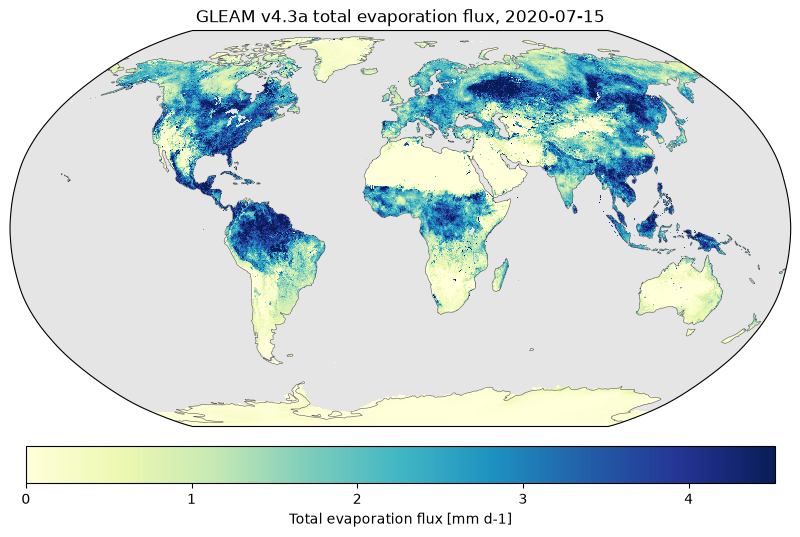

In [7]:
DAY = '2020-07-15'

daily_e = evaporation.sel(time=DAY).squeeze()
print(read_cost(daily_e))
daily_e = daily_e.compute()

figure = plt.figure(figsize=(11, 5.5))
ax = figure.add_subplot(1, 1, 1, projection=ccrs.Robinson())
image = draw_map(daily_e, ax, cmap='YlGnBu', vmin=0, vmax=robust_limits(daily_e)[1])
ax.set_title(f'GLEAM {VERSION} {evaporation.attrs["long_name"]}, {DAY}')
figure.colorbar(image, ax=ax, orientation='horizontal', pad=0.04, shrink=0.7,
                label=label(evaporation))
figure.tight_layout()

## 3. The evaporation components

`evaporation` is the sum of its six components, and `verify_gleam_zarr.py`
checks that identity holds to float32 rounding, so these seven maps are
consistent by construction. The check spans seven stores now rather than seven
variables of one store — the verifier reads the component stores alongside the
one holding the total, and only that store runs the identity, so it is not
repeated fourteen times.

Each panel gets **its own colour scale**, so the spatial structure of the small
terms is visible at all; on one shared scale transpiration swamps the other five
and they read as blank. The land-mean table underneath carries the magnitudes the
common scale would have shown, which is the honest way to have both.

The table also shows why a valid-cell mask has to be chosen deliberately here.
The components do not all share E's footprint — several are finite on a few
thousand cells where E is NaN — so averaging each over its own valid cells
compares different areas and the shares do not add up. Masking all of them to
E's footprint closes the sum to float32 rounding, which is the same identity the
verifier checks cell by cell.

6 chunks, ~148.3 MiB decompressed


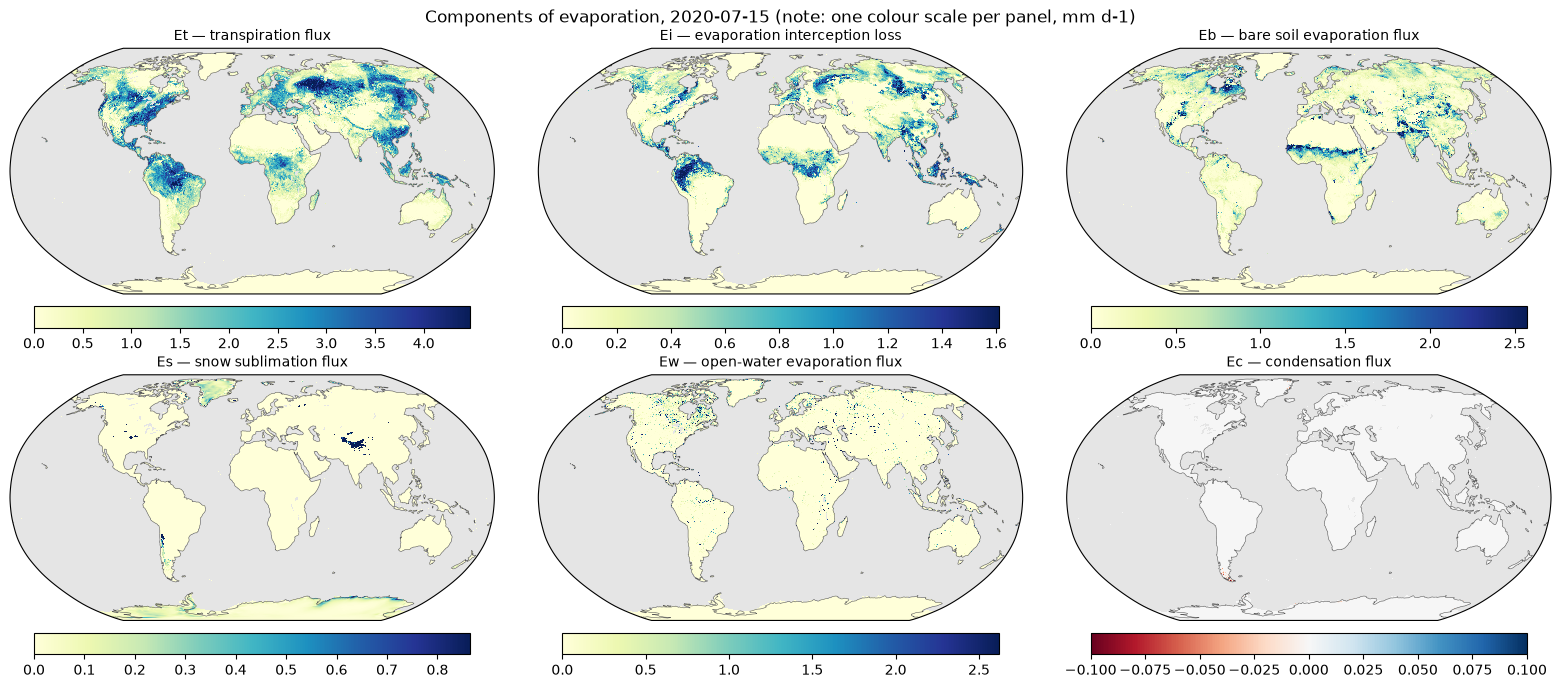

In [8]:
COMPONENTS = ['Et', 'Ei', 'Eb', 'Es', 'Ew', 'Ec']

components = open_family(COMPONENTS).sel(time=DAY).squeeze()
print(read_cost(components))
components = components.compute()

figure, axes = plt.subplots(
    2, 3, figsize=(16, 7), subplot_kw={'projection': ccrs.Robinson()}
)
for name, ax in zip(COMPONENTS, axes.ravel()):
    field = components[canonical(name)]
    # Ec is condensation and runs negative, so it needs a diverging scale
    # centred on zero rather than the sequential one the other five use
    diverging = float(field.min()) < 0
    vmin, vmax = robust_limits(field, low=1, high=99.5, symmetric=diverging)
    image = draw_map(field, ax, cmap='RdBu' if diverging else 'YlGnBu',
                     vmin=vmin if diverging else 0, vmax=vmax)
    # the canonical long names are already the short description the old
    # 'Transpiration from GLEAM 4.3a' strings had to be cut down to
    ax.set_title(f"{name} — {field.attrs['long_name']}", fontsize=10)
    figure.colorbar(image, ax=ax, orientation='horizontal', pad=0.04, shrink=0.85)

figure.suptitle(
    f"Components of {canonical('E')}, {DAY} "
    f"(note: one colour scale per panel, {evaporation.attrs['units']})"
)
figure.tight_layout()

In [9]:
def land_mean(field):
    """Area-weighted mean over the cells that carry data.

    Grid cells shrink towards the poles, so an unweighted mean over a lat/lon
    grid over-counts high latitudes; cos(lat) is the weight that corrects it.
    NaN cells -- ocean, and any fill -- drop out of both sums.

    Args:
        field (xr.DataArray): A computed (lat, lon) field.

    Returns:
        float: The area-weighted mean of the finite cells.
    """
    weights = np.cos(np.deg2rad(field['lat']))
    return float(field.weighted(weights).mean(['lat', 'lon']))


# Et, Eb, Es and Ec carry data on a few thousand cells where E itself is NaN.
# weighted().mean() renormalises over whatever cells are finite, so averaging
# each variable over its own footprint compares them on different areas and the
# shares come out not summing to 100. Restricting every component to the cells
# where E is finite is what makes the comparison an equal footing one.
footprint = daily_e.notnull()
wider = {
    name: int((components[canonical(name)].notnull() & ~footprint).sum())
    for name in COMPONENTS
}
print(f'cells with component data but no E: {wider}')

units = evaporation.attrs['units']
totals = pd.DataFrame(
    [
        {'component': name,
         f'land mean [{units}]': land_mean(components[canonical(name)].where(footprint)),
         'share of E [%]': (100 * land_mean(components[canonical(name)].where(footprint))
                            / land_mean(daily_e))}
        for name in COMPONENTS
    ]
).set_index('component')
totals.loc['sum of components'] = [
    totals[f'land mean [{units}]'].sum(), totals['share of E [%]'].sum()
]
totals.loc['E'] = [land_mean(daily_e), 100.0]

print(f'land-mean components against E, {DAY}')
totals.round(4)

cells with component data but no E: {'Et': 5488, 'Ei': 1, 'Eb': 5488, 'Es': 5258, 'Ew': 0, 'Ec': 5488}
land-mean components against E, 2020-07-15


,land mean [mm d-1],share of E [%]
component,,
Et,1.0218,62.4326
Ei,0.2312,14.1261
Eb,0.2813,17.1849
Es,0.0219,1.3362
Ew,0.0806,4.9229
Ec,-0.0000,-0.0026
sum of components,1.6367,100.0000
E,1.6367,100.0000


## 4. Monthly means and a seasonal difference

This is the first cell that costs real I/O, and the first that reads more than
one store: a month of one variable is ~31 chunks, and three variables over July
is three stores' worth of that. The two months are loaded once here and reused
by the plots that follow, so nothing below reads the stores again.

In [10]:
SUMMER = '2020-07'
WINTER = '2020-01'

EVAP = canonical('E')
SMRZ = canonical('SMrz')
STRESS = canonical('S')

fields = open_family(['E', 'SMrz', 'S'])
summer_selection = fields.sel(time=SUMMER)
winter_selection = fields[[EVAP]].sel(time=WINTER)
print(read_cost(summer_selection, winter_selection))

summer = summer_selection.mean('time', keep_attrs=True).compute()
winter = winter_selection.mean('time', keep_attrs=True).compute()

124 chunks, ~3.0 GiB decompressed


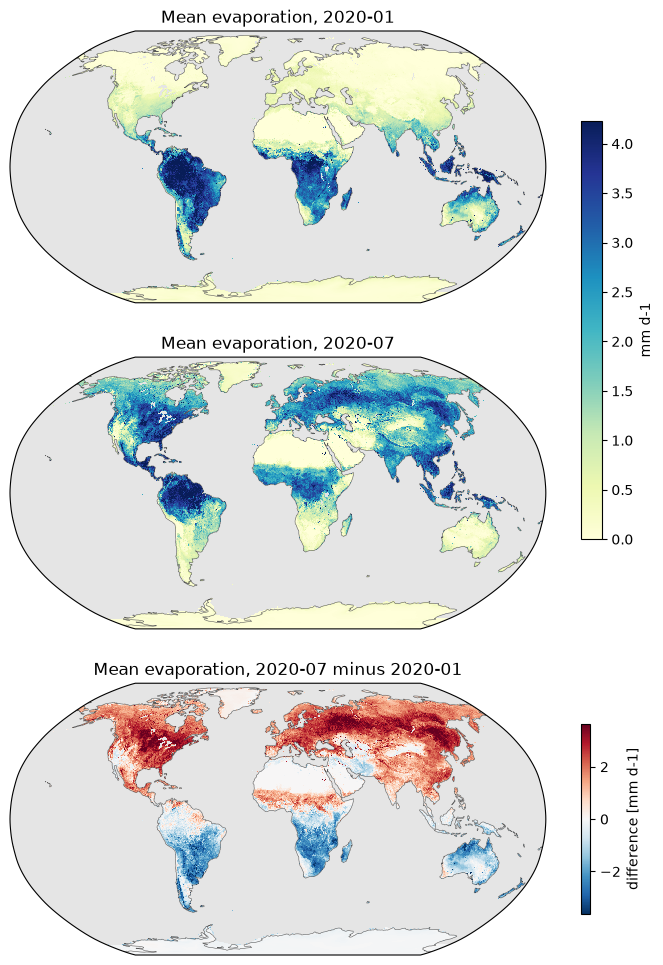

In [11]:
difference = summer[EVAP] - winter[EVAP]
bound = robust_limits(difference, low=1, high=99, symmetric=True)[1]

figure, axes = plt.subplots(
    3, 1, figsize=(9, 12), subplot_kw={'projection': ccrs.Robinson()}
)

evaporation_max = robust_limits(summer[EVAP], high=99)[1]
for ax, field, month in (
    (axes[0], winter[EVAP], WINTER), (axes[1], summer[EVAP], SUMMER)
):
    image = draw_map(field, ax, cmap='YlGnBu', vmin=0, vmax=evaporation_max)
    ax.set_title(f'Mean {EVAP}, {month}')
figure.colorbar(image, ax=axes[:2], orientation='vertical', shrink=0.7,
                label=summer[EVAP].attrs['units'])

image = draw_map(difference, axes[2], cmap='RdBu_r', vmin=-bound, vmax=bound)
axes[2].set_title(f'Mean {EVAP}, {SUMMER} minus {WINTER}')
figure.colorbar(image, ax=axes[2], orientation='vertical', shrink=0.7,
                label=f"difference [{summer[EVAP].attrs['units']}]")

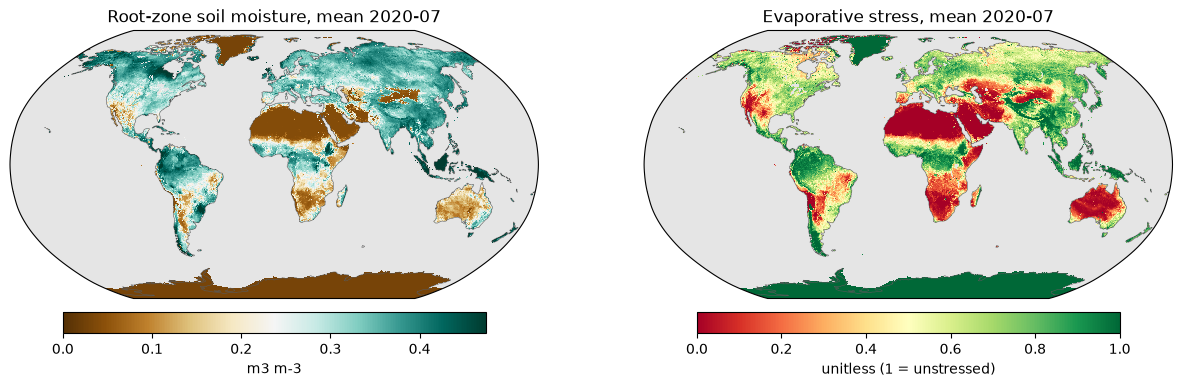

In [12]:
figure, axes = plt.subplots(
    1, 2, figsize=(15, 4.5), subplot_kw={'projection': ccrs.Robinson()}
)

image = draw_map(summer[SMRZ], axes[0], cmap='BrBG', vmin=0,
                 vmax=robust_limits(summer[SMRZ], high=99)[1])
axes[0].set_title(f'Root-zone soil moisture, mean {SUMMER}')
figure.colorbar(image, ax=axes[0], orientation='horizontal', pad=0.04, shrink=0.8,
                label=summer[SMRZ].attrs['units'])

image = draw_map(summer[STRESS], axes[1], cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_title(f'Evaporative stress, mean {SUMMER}')
# the canonical units are 'unitless' rather than GLEAM's '-', which is not a
# udunits token; the scale is worth spelling out either way
figure.colorbar(image, ax=axes[1], orientation='horizontal', pad=0.04, shrink=0.8,
                label=f"{summer[STRESS].attrs['units']} (1 = unstressed)")

## 5. A regional zoom

Subsetting in space costs nothing extra *and saves nothing*: the July means are
already in memory, so this is pure plotting. Note the latitude slice runs north
to south, matching the store's descending `lat` coordinate — `slice(24, 50)`
would return an empty selection.

An equal-area conic projection suits a mid-latitude region better than Robinson.
Only coastlines are drawn: state and country boundaries live in Natural Earth's
cultural files, which are not cached here.

Text(0.5, 0.98, 'contiguous United States')

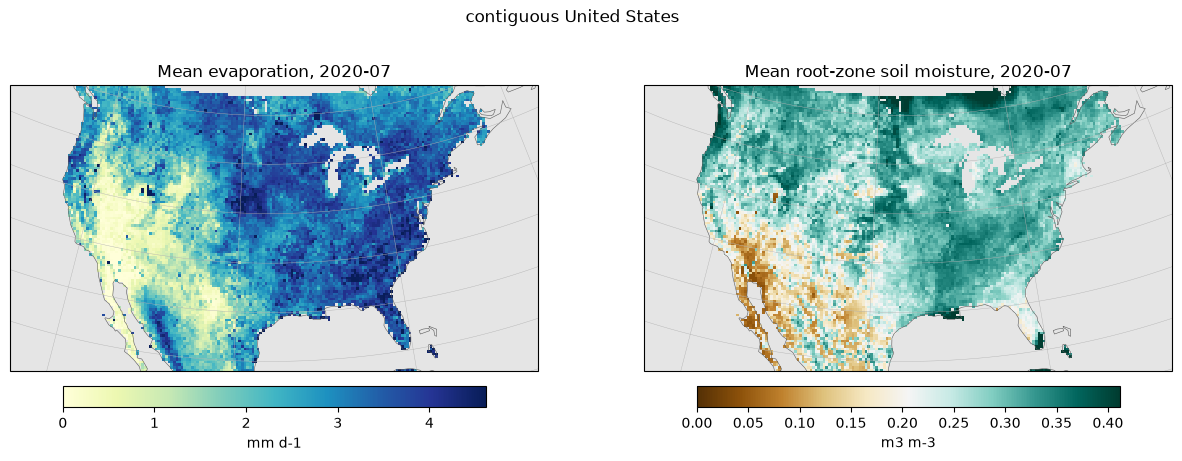

In [13]:
REGION = {'name': 'contiguous United States',
          'extent': [-125, -66, 24, 50],
          'lat': slice(52, 22), 'lon': slice(-127, -64)}

projection = ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))
figure, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': projection})

regional_e = summer[EVAP].sel(lat=REGION['lat'], lon=REGION['lon'])
image = draw_map(regional_e, axes[0], cmap='YlGnBu', vmin=0,
                 vmax=robust_limits(regional_e, high=99)[1], extent=REGION['extent'])
axes[0].set_title(f'Mean {EVAP}, {SUMMER}')
figure.colorbar(image, ax=axes[0], orientation='horizontal', pad=0.04, shrink=0.8,
                label=summer[EVAP].attrs['units'])

regional_sm = summer[SMRZ].sel(lat=REGION['lat'], lon=REGION['lon'])
image = draw_map(regional_sm, axes[1], cmap='BrBG', vmin=0,
                 vmax=robust_limits(regional_sm, high=99)[1], extent=REGION['extent'])
axes[1].set_title(f'Mean root-zone soil moisture, {SUMMER}')
figure.colorbar(image, ax=axes[1], orientation='horizontal', pad=0.04, shrink=0.8,
                label=summer[SMRZ].attrs['units'])

for ax in axes:
    ax.gridlines(draw_labels=False, linewidth=0.3, color='0.7')
figure.suptitle(REGION['name'])

## 6. The known gap in `evaporation`

`evaporation` is entirely fill on 25 days — five 5-day blocks in 1982 and 1992 —
while every other variable, including its own components, has data on those days.
That is a gap in upstream GLEAM v4.3a, not a conversion defect, and it is
recorded in the store's `known_data_gaps` attribute. Zarr does not write a chunk
whose cells are all fill, so this store holds 16,777 chunks against 16,802
timesteps and that is correct: the missing chunk reads back as NaN.

Only the `evaporation` store carries that attribute. The gap is a property of
one variable, and now that each variable has a store of its own, a store must
not carry a note about data it does not hold — which is also why `open_family`
drops global attributes rather than merging them.

Worth knowing before an average over 1992 comes out looking odd. `isnull()`
finds the gap days cheaply only if you already know where to look; the attribute
is the cheap route.

This variable is entirely fill (NaN) on 25 days -- five 5-day blocks, 1982-02-05..02-09 and 1992-01-01..01-05, 03-21..03-25, 05-20..05-24 and 10-02..10-06 -- while every other GLEAM variable, including E's own components, has data on those days. This is a gap in upstream GLEAM v4.3a, not a conversion defect. Zarr does not write a chunk whose cells are all fill, so this store holds 16777 chunks against 16802 timesteps and that is correct.

transpiration store carries known_data_gaps: False
2 chunks, ~49.4 MiB decompressed


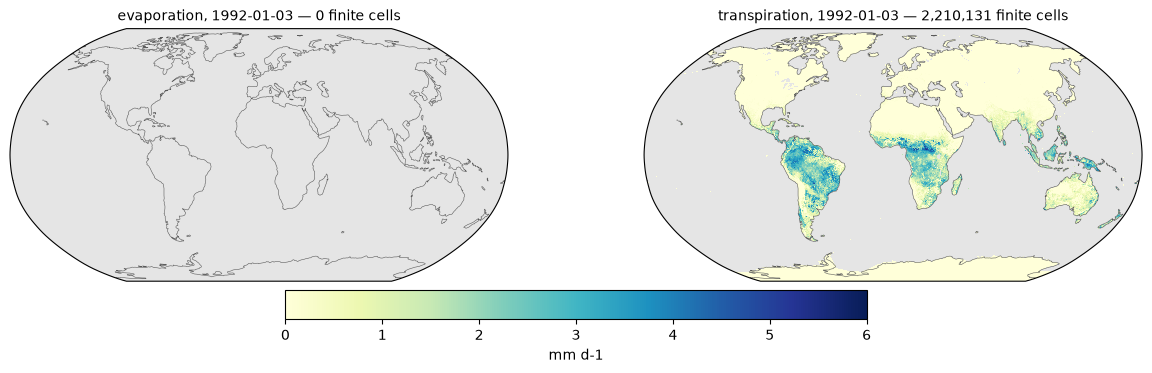

In [14]:
print(open_store('E').attrs['known_data_gaps'])

# the note is on E's store alone -- the components have data on these days
print(
    '\ntranspiration store carries known_data_gaps: '
    f"{'known_data_gaps' in open_store('Et').attrs}"
)

GAP_DAY = '1992-01-03'

gap = open_family(['E', 'Et']).sel(time=GAP_DAY).squeeze()
print(read_cost(gap))
gap = gap.compute()

figure, axes = plt.subplots(
    1, 2, figsize=(15, 4), subplot_kw={'projection': ccrs.Robinson()}
)
for ax, name in zip(axes, ['E', 'Et']):
    field = gap[canonical(name)]
    finite = int(np.isfinite(field.values).sum())
    image = draw_map(field, ax, cmap='YlGnBu', vmin=0, vmax=6)
    ax.set_title(f'{canonical(name)}, {GAP_DAY} — {finite:,} finite cells', fontsize=10)
figure.colorbar(image, ax=axes, orientation='horizontal', pad=0.03, shrink=0.5,
                label=evaporation.attrs['units'])

## 7. Time series: this layout, and the sibling built for them

Here is the cost model from section 1 made concrete. The regional daily mean
below covers 60 days of one variable, so it reads 60 whole global chunks — about
1.5 GiB — to produce 60 numbers, and clipping to a region does not reduce that
by a single byte.

Sixty days is affordable. The same call over the full 46-year record would read
~400 GiB, and that is what the **temporal layout** exists for. The same fourteen
variables are built a second time under `temporal/`, chunked
`(time, lat, lon) = (16802, 20, 20)` — one 2x2 degree tile through the whole
record, 25.6 MiB. Nothing but the chunking differs, so the two layouts answer
every question identically; they disagree only about which questions are
affordable.

The two were built from raw and verified against raw independently, so neither
has to be trusted to trust the other, and each store's `related_store` attribute
names its opposite number. The second cell below pulls a full-record point
series out of the sibling: one chunk, against the 16,802 the same series would
cost here.

60 chunks, ~1.4 GiB decompressed


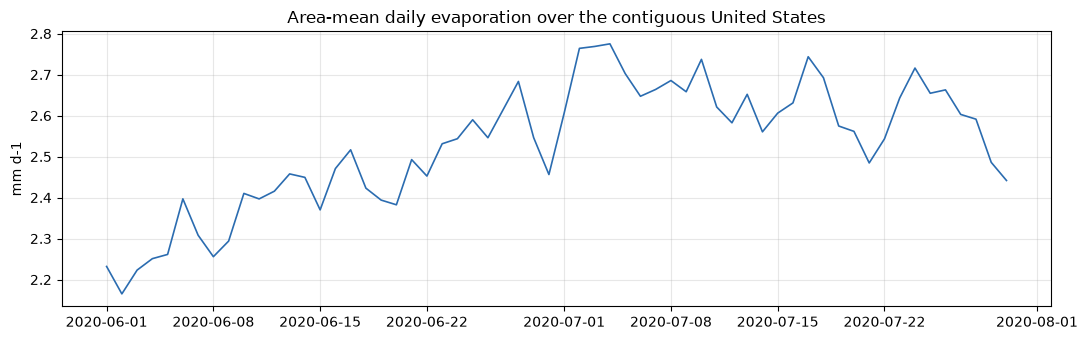

In [15]:
WINDOW = slice('2020-06-01', '2020-07-30')

regional = open_array('E').sel(time=WINDOW, lat=REGION['lat'], lon=REGION['lon'])
# cos(lat) weighted, the same as land_mean above, but vectorised over time
# rather than applied a day at a time; weighted().mean() drops NaN cells and
# renormalises, so ocean and any fill stay out of the average
weights = np.cos(np.deg2rad(regional['lat']))
series_lazy = regional.weighted(weights).mean(['lat', 'lon'])

# the cost is set by the time slice alone: the lat/lon selection happens after
# each whole global chunk has already been read and decompressed, so the
# unsubset selection is what read_cost has to be shown
print(read_cost(evaporation.sel(time=WINDOW)))

series = series_lazy.compute()

figure, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(series['time'], series.values, color='#2b6cb0', linewidth=1.2)
ax.set_ylabel(evaporation.attrs['units'])
ax.set_title(f"Area-mean daily {EVAP} over the {REGION['name']}")
ax.grid(alpha=0.3)
figure.tight_layout()

  2026-09-16T22:29:31.468175Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329



  spatial: 16802 chunks, ~405.6 GiB decompressed
 temporal: 1 chunk, ~25.6 MiB decompressed

related_store: temporal/gleam.v_4_3_a.day.native_0p1x0p1.evaporation.zarr -- the same variable on the same grid over the same period, chunked for the opposite access pattern. Identical values; the two differ only in chunking.


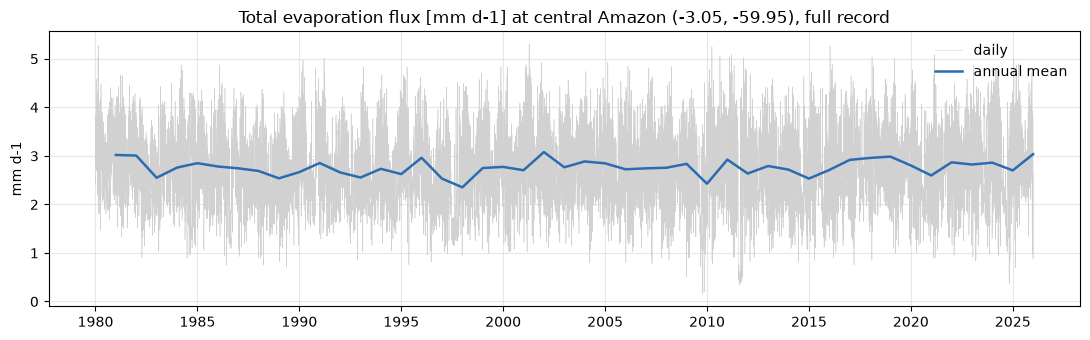

In [16]:
POINT = {'name': 'central Amazon', 'lat': -3.1, 'lon': -60.0}

sibling = open_array('E', suffix=SIBLING_SUFFIX)
point_lazy = sibling.sel(lat=POINT['lat'], lon=POINT['lon'], method='nearest')

# the same question put to each layout. the selection's own dask chunks are
# (16802, 1, 1) either way; what is read is the store chunk the cell falls in,
# which is why chunk_mib is taken off the unselected array
print(f'{SUFFIX:>9}: {read_cost(evaporation)}')
print(
    f'{SIBLING_SUFFIX:>9}: '
    f'{read_cost(point_lazy, mib_per_chunk=chunk_mib(sibling))}'
)
print(f'\nrelated_store: {open_store("E").attrs["related_store"]}')

point = point_lazy.compute()

# 16,802 daily values is noise at this width; the annual mean is what having
# the whole record cheaply is actually for
annual = point.resample(time='YE').mean()

figure, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(point['time'], point.values, color='0.82', linewidth=0.4, label='daily')
ax.plot(annual['time'], annual.values, color='#2b6cb0', linewidth=1.8,
        label='annual mean')
ax.set_ylabel(sibling.attrs['units'])
ax.set_title(
    f"{label(sibling)} at {POINT['name']} "
    f"({float(point.lat):.2f}, {float(point.lon):.2f}), full record"
)
ax.legend(loc='upper right', frameon=False)
ax.grid(alpha=0.3)
figure.tight_layout()